In [41]:
import kagglehub
import pandas as pd
import numpy as np

# Fijamos semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Descarga del dataset
path = kagglehub.dataset_download("arianazmoudeh/airbnbopendata")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Pepe\.cache\kagglehub\datasets\arianazmoudeh\airbnbopendata\versions\1


In [42]:
import os

# Listamos los archivos descargados para saber el nombre exacto del CSV
print(os.listdir(path))

['Airbnb_Open_Data.csv']


In [43]:
# Cargamos el CSV (ajusta el nombre según lo que arroje el listdir anterior)
df = pd.read_csv(f"{path}/Airbnb_Open_Data.csv")

# Dimensiones del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 102599
Columnas: 26


C:\Users\Pepe\AppData\Local\Temp\ipykernel_43112\1338851031.py:2: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/Airbnb_Open_Data.csv")


In [44]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [45]:
# Tipos de datos y nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str    
 11  instant_bookable                102494 non-null  object 
 12  cancellation_policy        

In [46]:
# Resumen de nulos ordenado de mayor a menor
df.isnull().sum().sort_values(ascending=False)

license                           102597
house_rules                        52131
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            406
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service fee                          273
NAME                                 250
price                                247
Construction year                    214
number of reviews                    183
country code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                                     0
host id         

In [47]:
# Revisamos valores únicos de las columnas categóricas clave para detectar
# inconsistencias de texto (typos, mayúsculas/minúsculas, etc.)
cat_cols = ['neighbourhood group', 'room type', 'cancellation_policy',
            'instant_bookable', 'host_identity_verified', 'country', 'country code']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- neighbourhood group ---
neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
NaN                 29
brookln              1
manhatan             1
Name: count, dtype: int64

--- room type ---
room type
Entire home/apt    53701
Private room       46556
Shared room         2226
Hotel room           116
Name: count, dtype: int64

--- cancellation_policy ---
cancellation_policy
moderate    34343
strict      34106
flexible    34074
NaN            76
Name: count, dtype: int64

--- instant_bookable ---
instant_bookable
False    51474
True     51020
NaN        105
Name: count, dtype: int64

--- host_identity_verified ---
host_identity_verified
unconfirmed    51200
verified       51110
NaN              289
Name: count, dtype: int64

--- country ---
country
United States    102067
NaN                 532
Name: count, dtype: int64

--- country code ---
country code
US     102468
NaN       131
Name: count, dtype: 

In [48]:
# Vistazo rápido a 'price' y 'service fee' para ver el formato exacto
print(df['price'].dropna().unique()[:10])
print(df['service fee'].dropna().unique()[:10])

<StringArray>
[  '$966 ',   '$142 ',   '$620 ',   '$368 ',   '$204 ',   '$577 ',    '$71 ',
 '$1,060 ', '$1,018 ',   '$291 ']
Length: 10, dtype: str
<StringArray>
['$193 ',  '$28 ', '$124 ',  '$74 ',  '$41 ', '$115 ',  '$14 ', '$212 ',
 '$204 ',  '$58 ']
Length: 10, dtype: str


In [49]:
# Revisemos también duplicados exactos y duplicados por 'id'
print("Filas duplicadas exactas:", df.duplicated().sum())
print("IDs duplicados:", df['id'].duplicated().sum())

Filas duplicadas exactas: 541
IDs duplicados: 541


In [50]:
# --- 1. Eliminar duplicados exactos ---
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 102058


In [51]:
# --- 2. Corregir typos en 'neighbourhood group' ---
df['neighbourhood group'] = df['neighbourhood group'].replace({
    'manhatan': 'Manhattan',
    'brookln': 'Brooklyn'
})
print(df['neighbourhood group'].value_counts(dropna=False))

neighbourhood group
Manhattan        43558
Brooklyn         41631
Queens           13197
Bronx             2694
Staten Island      949
NaN                 29
Name: count, dtype: int64


In [52]:
# --- 3. Limpiar 'price' y 'service fee': quitar '$', ',', espacios y convertir a float ---
for col in ['price', 'service fee']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')  # los NaN originales se mantienen como NaN

print(df[['price', 'service fee']].describe())

               price    service fee
count  101811.000000  101785.000000
mean      625.355580     125.039249
std       331.672649      66.325905
min        50.000000      10.000000
25%       340.000000      68.000000
50%       625.000000     125.000000
75%       913.000000     183.000000
max      1200.000000     240.000000


In [53]:
# --- 4. Renombrar columnas con espacios a snake_case (buena práctica, evita errores futuros) ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license']


In [54]:
# --- 5. Revisar nulos restantes tras la limpieza ---
df.isnull().sum().sort_values(ascending=False)

license                           102056
house_rules                        51842
last_review                        15832
reviews_per_month                  15818
country                              532
availability_365                     448
host_name                            404
minimum_nights                       400
calculated_host_listings_count       319
review_rate_number                   319
host_identity_verified               289
service_fee                          273
name                                 250
price                                247
construction_year                    214
number_of_reviews                    183
country_code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood_group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                                     0
host_id         

In [55]:
# Columnas actuales tras el renombrado
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license']


In [56]:
# Revisemos 'minimum_nights' y 'availability_365' — clásicos candidatos a outliers
print(df['minimum_nights'].describe())
print()
print(df['availability_365'].describe())

count    101658.000000
mean          8.126640
std          30.616698
min       -1223.000000
25%           2.000000
50%           3.000000
75%           5.000000
max        5645.000000
Name: minimum_nights, dtype: float64

count    101610.000000
mean        141.043992
std         135.429156
min         -10.000000
25%           3.000000
50%          96.000000
75%         268.000000
max        3677.000000
Name: availability_365, dtype: float64


In [57]:
# Valores fuera de rango lógico:
# minimum_nights negativo no tiene sentido; availability_365 no debería superar 365
print("minimum_nights negativos:", (df['minimum_nights'] < 0).sum())
print("availability_365 > 365:", (df['availability_365'] > 365).sum())
print("availability_365 negativos:", (df['availability_365'] < 0).sum())

minimum_nights negativos: 13
availability_365 > 365: 2754
availability_365 negativos: 431


In [58]:
# Decisión sobre columnas casi vacías / poco útiles
# license: 102597 nulos de ~102k filas -> se elimina
# house_rules: texto libre, ~51% nulo -> se elimina del análisis cuantitativo
#              (no aporta a variables categóricas/continuas estructuradas)
# country / country_code: prácticamente constantes -> se eliminan (no distinguen nada)
df = df.drop(columns=['license', 'house_rules', 'country', 'country_code'])
print(df.shape)

(102058, 22)


In [59]:
# Cuantifiquemos cuántas filas están afectadas por estos valores imposibles
print("minimum_nights negativos:", (df['minimum_nights'] < 0).sum())
print("minimum_nights > 365 (poco realista para un Airbnb):", (df['minimum_nights'] > 365).sum())
print()
print("availability_365 negativos:", (df['availability_365'] < 0).sum())
print("availability_365 > 365:", (df['availability_365'] > 365).sum())

minimum_nights negativos: 13
minimum_nights > 365 (poco realista para un Airbnb): 35

availability_365 negativos: 431
availability_365 > 365: 2754


In [60]:
# Criterio de limpieza (a justificar en el informe):
# - availability_365 tiene un límite físico claro (0-365). Los valores fuera de ese
#   rango son errores de captura -> se corrigen a NaN (no se puede "adivinar" el valor real).
df.loc[(df['availability_365'] < 0) | (df['availability_365'] > 365), 'availability_365'] = np.nan

# - minimum_nights negativo no tiene sentido físico -> se pasa a NaN.
#   Valores muy altos (ej. >365) sí pueden ser reales (alquileres de largo plazo),
#   así que NO los tocamos aquí; se evaluarán con criterio cuantitativo (IQR/z-score)
#   en el paso de detección de outliers, no como error de captura.
df.loc[df['minimum_nights'] < 0, 'minimum_nights'] = np.nan

print(df[['minimum_nights', 'availability_365']].describe())

       minimum_nights  availability_365
count   101645.000000      98425.000000
mean         8.147120        134.528484
std         30.341361        129.805264
min          1.000000          0.000000
25%          2.000000          2.000000
50%          3.000000         90.000000
75%          5.000000        254.000000
max       5645.000000        365.000000


In [61]:
# --- Detección de outliers con criterio cuantitativo (IQR) ---
def contar_outliers_iqr(serie, nombre):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"{nombre}: límites [{lim_inf:.1f}, {lim_sup:.1f}] -> {outliers.shape[0]} outliers")
    return lim_inf, lim_sup

for col in ['price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'availability_365']:
    contar_outliers_iqr(df[col].dropna(), col)

price: límites [-519.5, 1772.5] -> 0 outliers
service_fee: límites [-104.5, 355.5] -> 0 outliers
minimum_nights: límites [-2.5, 9.5] -> 18240 outliers
number_of_reviews: límites [-44.0, 76.0] -> 11120 outliers
availability_365: límites [-376.0, 632.0] -> 0 outliers


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

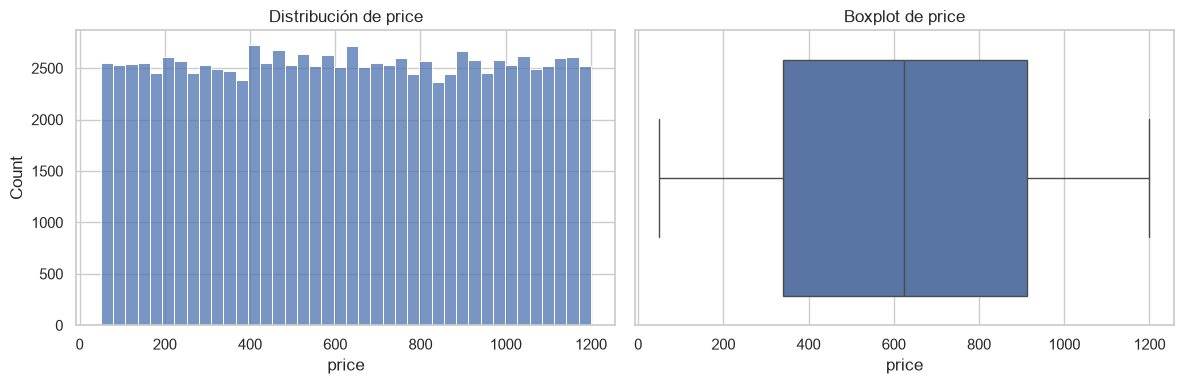

In [63]:
# --- Univariada: distribución de precios ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'].dropna(), bins=40, ax=axes[0])
axes[0].set_title('Distribución de price')

sns.boxplot(x=df['price'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot de price')
plt.tight_layout()
plt.show()

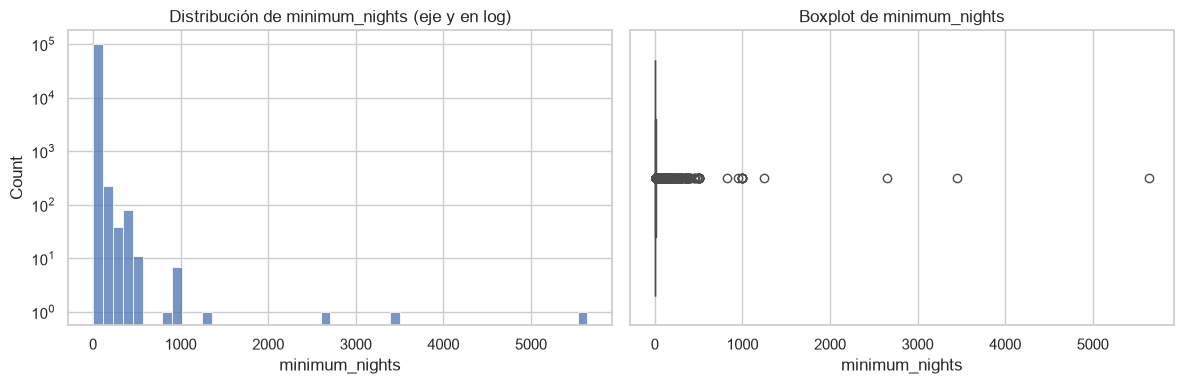

In [64]:
# --- Univariada: minimum_nights (escala log por su asimetría) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['minimum_nights'].dropna(), bins=50, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Distribución de minimum_nights (eje y en log)')

sns.boxplot(x=df['minimum_nights'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot de minimum_nights')
plt.tight_layout()
plt.show()

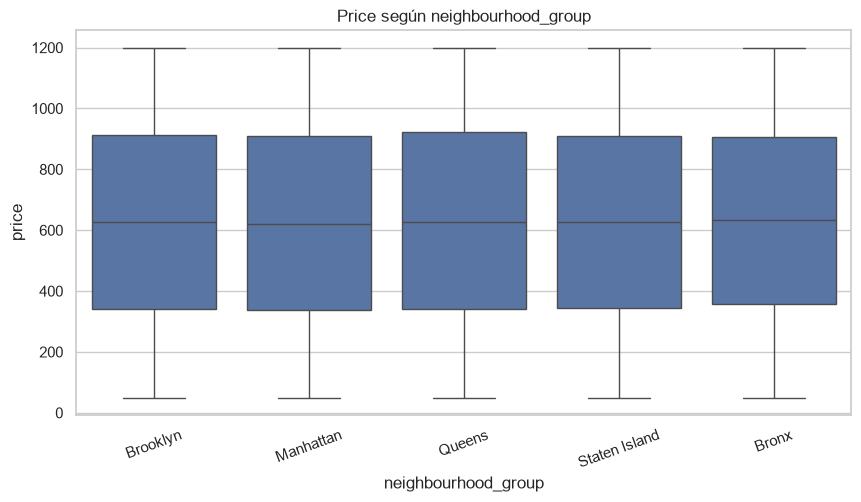

In [65]:
# --- Bivariada: price según neighbourhood_group ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price')
plt.title('Price según neighbourhood_group')
plt.xticks(rotation=20)
plt.show()

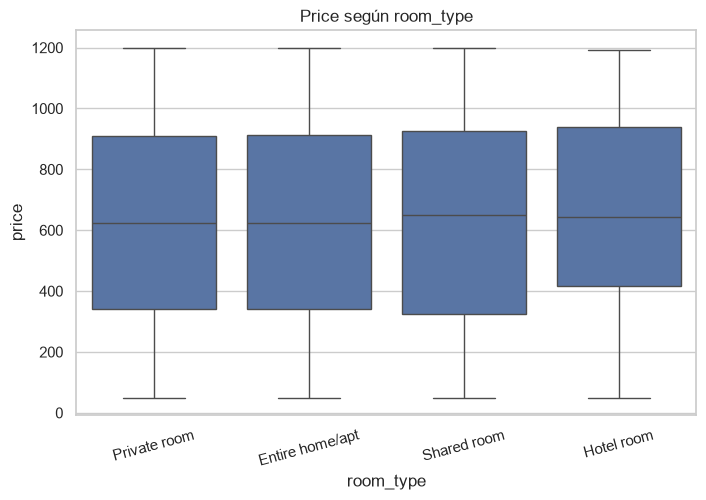

In [66]:
# --- Bivariada: price según room_type ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price según room_type')
plt.xticks(rotation=15)
plt.show()

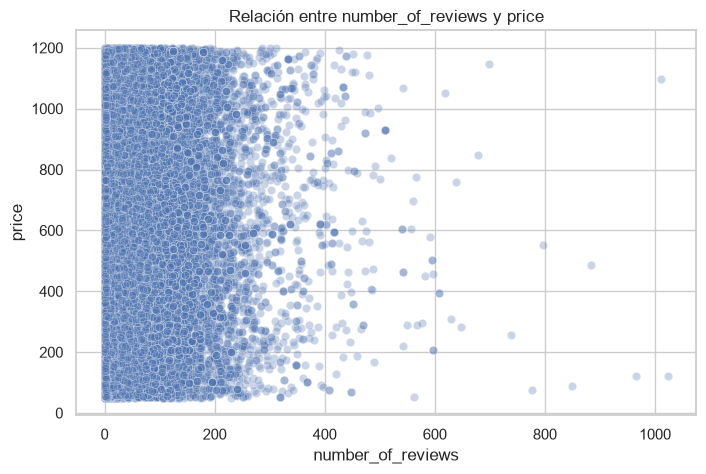

In [67]:
# --- Bivariada: number_of_reviews vs price (scatter) ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='number_of_reviews', y='price', alpha=0.3)
plt.title('Relación entre number_of_reviews y price')
plt.show()

In [68]:
# Estadísticos descriptivos de review_rate_number por grupo
print(df.groupby('cancellation_policy')['review_rate_number'].describe())
print()
print(df.groupby('instant_bookable')['review_rate_number'].describe())

                       count      mean       std  min  25%  50%  75%  max
cancellation_policy                                                      
flexible             33781.0  3.279861  1.282253  1.0  2.0  3.0  4.0  5.0
moderate             34061.0  3.279146  1.284373  1.0  2.0  3.0  4.0  5.0
strict               33821.0  3.277165  1.288417  1.0  2.0  3.0  4.0  5.0

                    count      mean       std  min  25%  50%  75%  max
instant_bookable                                                      
False             51046.0  3.274654  1.283784  1.0  2.0  3.0  4.0  5.0
True              50602.0  3.282815  1.286276  1.0  2.0  3.0  4.0  5.0


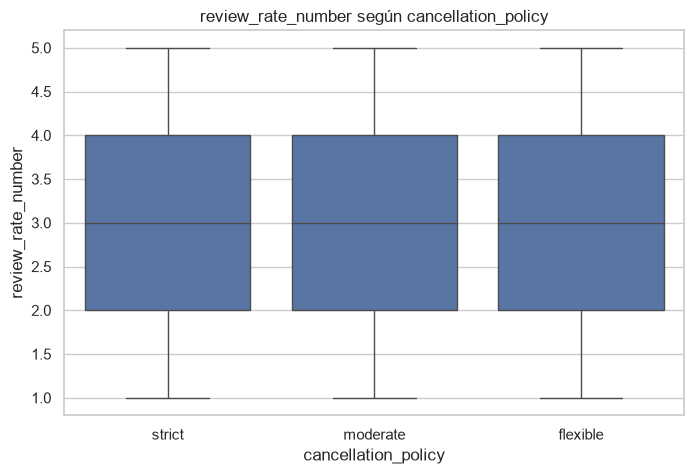

In [69]:
# Visualización bivariada: boxplot de review_rate_number por cancellation_policy
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='cancellation_policy', y='review_rate_number')
plt.title('review_rate_number según cancellation_policy')
plt.show()

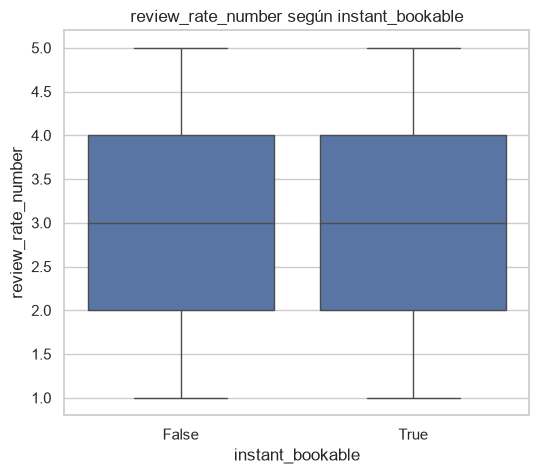

In [70]:
# Visualización bivariada: boxplot de review_rate_number por instant_bookable
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='instant_bookable', y='review_rate_number')
plt.title('review_rate_number según instant_bookable')
plt.show()

In [71]:
# Prueba de asociación cuantitativa:
from scipy import stats

# ANOVA para cancellation_policy (3 grupos: moderate, strict, flexible)
grupos_cp = [g['review_rate_number'].dropna() for _, g in df.groupby('cancellation_policy')]
f_stat, p_val = stats.f_oneway(*grupos_cp)
print(f"ANOVA cancellation_policy: F={f_stat:.4f}, p-valor={p_val:.4f}")

# Prueba t para instant_bookable (2 grupos: True/False)
grupo_true = df[df['instant_bookable'] == True]['review_rate_number'].dropna()
grupo_false = df[df['instant_bookable'] == False]['review_rate_number'].dropna()
t_stat, p_val_t = stats.ttest_ind(grupo_true, grupo_false, equal_var=False)
print(f"T-test instant_bookable: t={t_stat:.4f}, p-valor={p_val_t:.4f}")

ANOVA cancellation_policy: F=0.0400, p-valor=0.9608
T-test instant_bookable: t=1.0123, p-valor=0.3114


In [72]:
# Tabla de contingencia entre room_type y neighbourhood_group
tabla_contingencia = pd.crosstab(df['neighbourhood_group'], df['room_type'])
print(tabla_contingencia)

room_type            Entire home/apt  Hotel room  Private room  Shared room
neighbourhood_group                                                        
Bronx                           1020           0          1559          115
Brooklyn                       20475           7         20325          824
Manhattan                      26331         100         16232          895
Queens                          5118           8          7712          359
Staten Island                    474           0           460           15


In [73]:
# Test chi-cuadrado de independencia
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print(f"Chi2 = {chi2:.2f}, p-valor = {p:.6f}, grados de libertad = {dof}")

Chi2 = 2708.85, p-valor = 0.000000, grados de libertad = 12


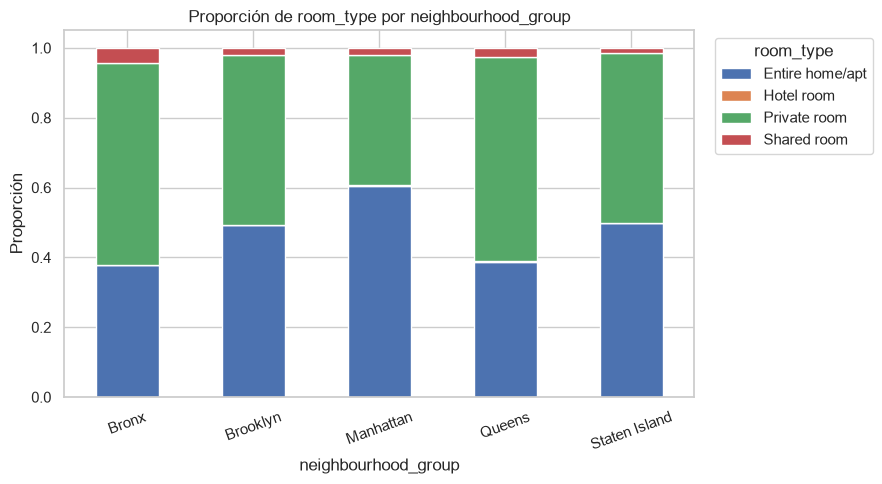

In [74]:
# Visualización: proporción de room_type dentro de cada neighbourhood_group
tabla_prop = pd.crosstab(df['neighbourhood_group'], df['room_type'], normalize='index')
tabla_prop.plot(kind='bar', stacked=True, figsize=(9, 5))
plt.title('Proporción de room_type por neighbourhood_group')
plt.ylabel('Proporción')
plt.xticks(rotation=20)
plt.legend(title='room_type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [75]:
tabla_contingencia = pd.crosstab(df['neighbourhood_group'], df['review_rate_number'])
print(tabla_contingencia)

review_rate_number    1.0   2.0   3.0   4.0    5.0
neighbourhood_group                               
Bronx                 165   593   692   644    583
Brooklyn             4012  9456  9179  9526   9342
Manhattan            4030  9713  9913  9745  10017
Queens                920  2990  3122  3076   3051
Staten Island          54   216   219   203    251


In [76]:
chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Grados de libertad: {dof}")

Estadístico Chi2: 162.5295
p-value: 0.0000
Grados de libertad: 16


In [77]:
alpha = 0.05
if p_value < alpha:
    print("Se rechaza H0: existe asociación significativa entre neighbourhood_group y review_rate_number")
else:
    print("No se rechaza H0: no hay evidencia suficiente de asociación")

Se rechaza H0: existe asociación significativa entre neighbourhood_group y review_rate_number


In [78]:
print("Mínimo valor esperado:", np.min(expected))

Mínimo valor esperado: 85.11958274343243


In [79]:
n = tabla_contingencia.sum().sum()
k = min(tabla_contingencia.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.0200


ANOVA neighbourhood_group: F=11.3048, p-valor=0.0000


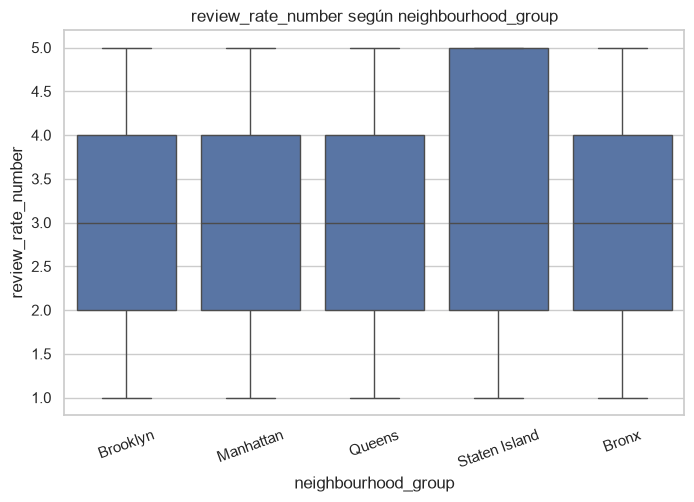

In [80]:
# ANOVA: review_rate_number según neighbourhood_group (5 grupos)
grupos_barrio = [g['review_rate_number'].dropna() for _, g in df.groupby('neighbourhood_group')]
f_stat, p_val = stats.f_oneway(*grupos_barrio)
print(f"ANOVA neighbourhood_group: F={f_stat:.4f}, p-valor={p_val:.4f}")

# Visualización de apoyo
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='neighbourhood_group', y='review_rate_number')
plt.title('review_rate_number según neighbourhood_group')
plt.xticks(rotation=20)
plt.show()

In [81]:
grupos_barrio = [g['review_rate_number'].dropna() for _, g in df.groupby('neighbourhood_group')]
f_stat, p_val = stats.f_oneway(*grupos_barrio)
print(f"ANOVA neighbourhood_group: F={f_stat:.4f}, p-valor={p_val:.4f}")


ANOVA neighbourhood_group: F=11.3048, p-valor=0.0000


In [ ]:
# Corrección de valores imposibles (agregar esto al bloque de limpieza real)
df.loc[(df['availability_365'] < 0) | (df['availability_365'] > 365), 'availability_365'] = np.nan
df.loc[df['minimum_nights'] < 0, 'minimum_nights'] = np.nan

print("availability_365 corregidos:", ((df['availability_365'] < 0) | (df['availability_365'] > 365)).sum())
print("minimum_nights negativos corregidos:", (df['minimum_nights'] < 0).sum())